In [ ]:
全天图

In [47]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np
import warnings
import matplotlib.patches as patches  # 新增：导入patches模块（原代码用了但没导入）
from astropy.io.fits.verify import VerifyWarning
from astropy.wcs import FITSFixedWarning

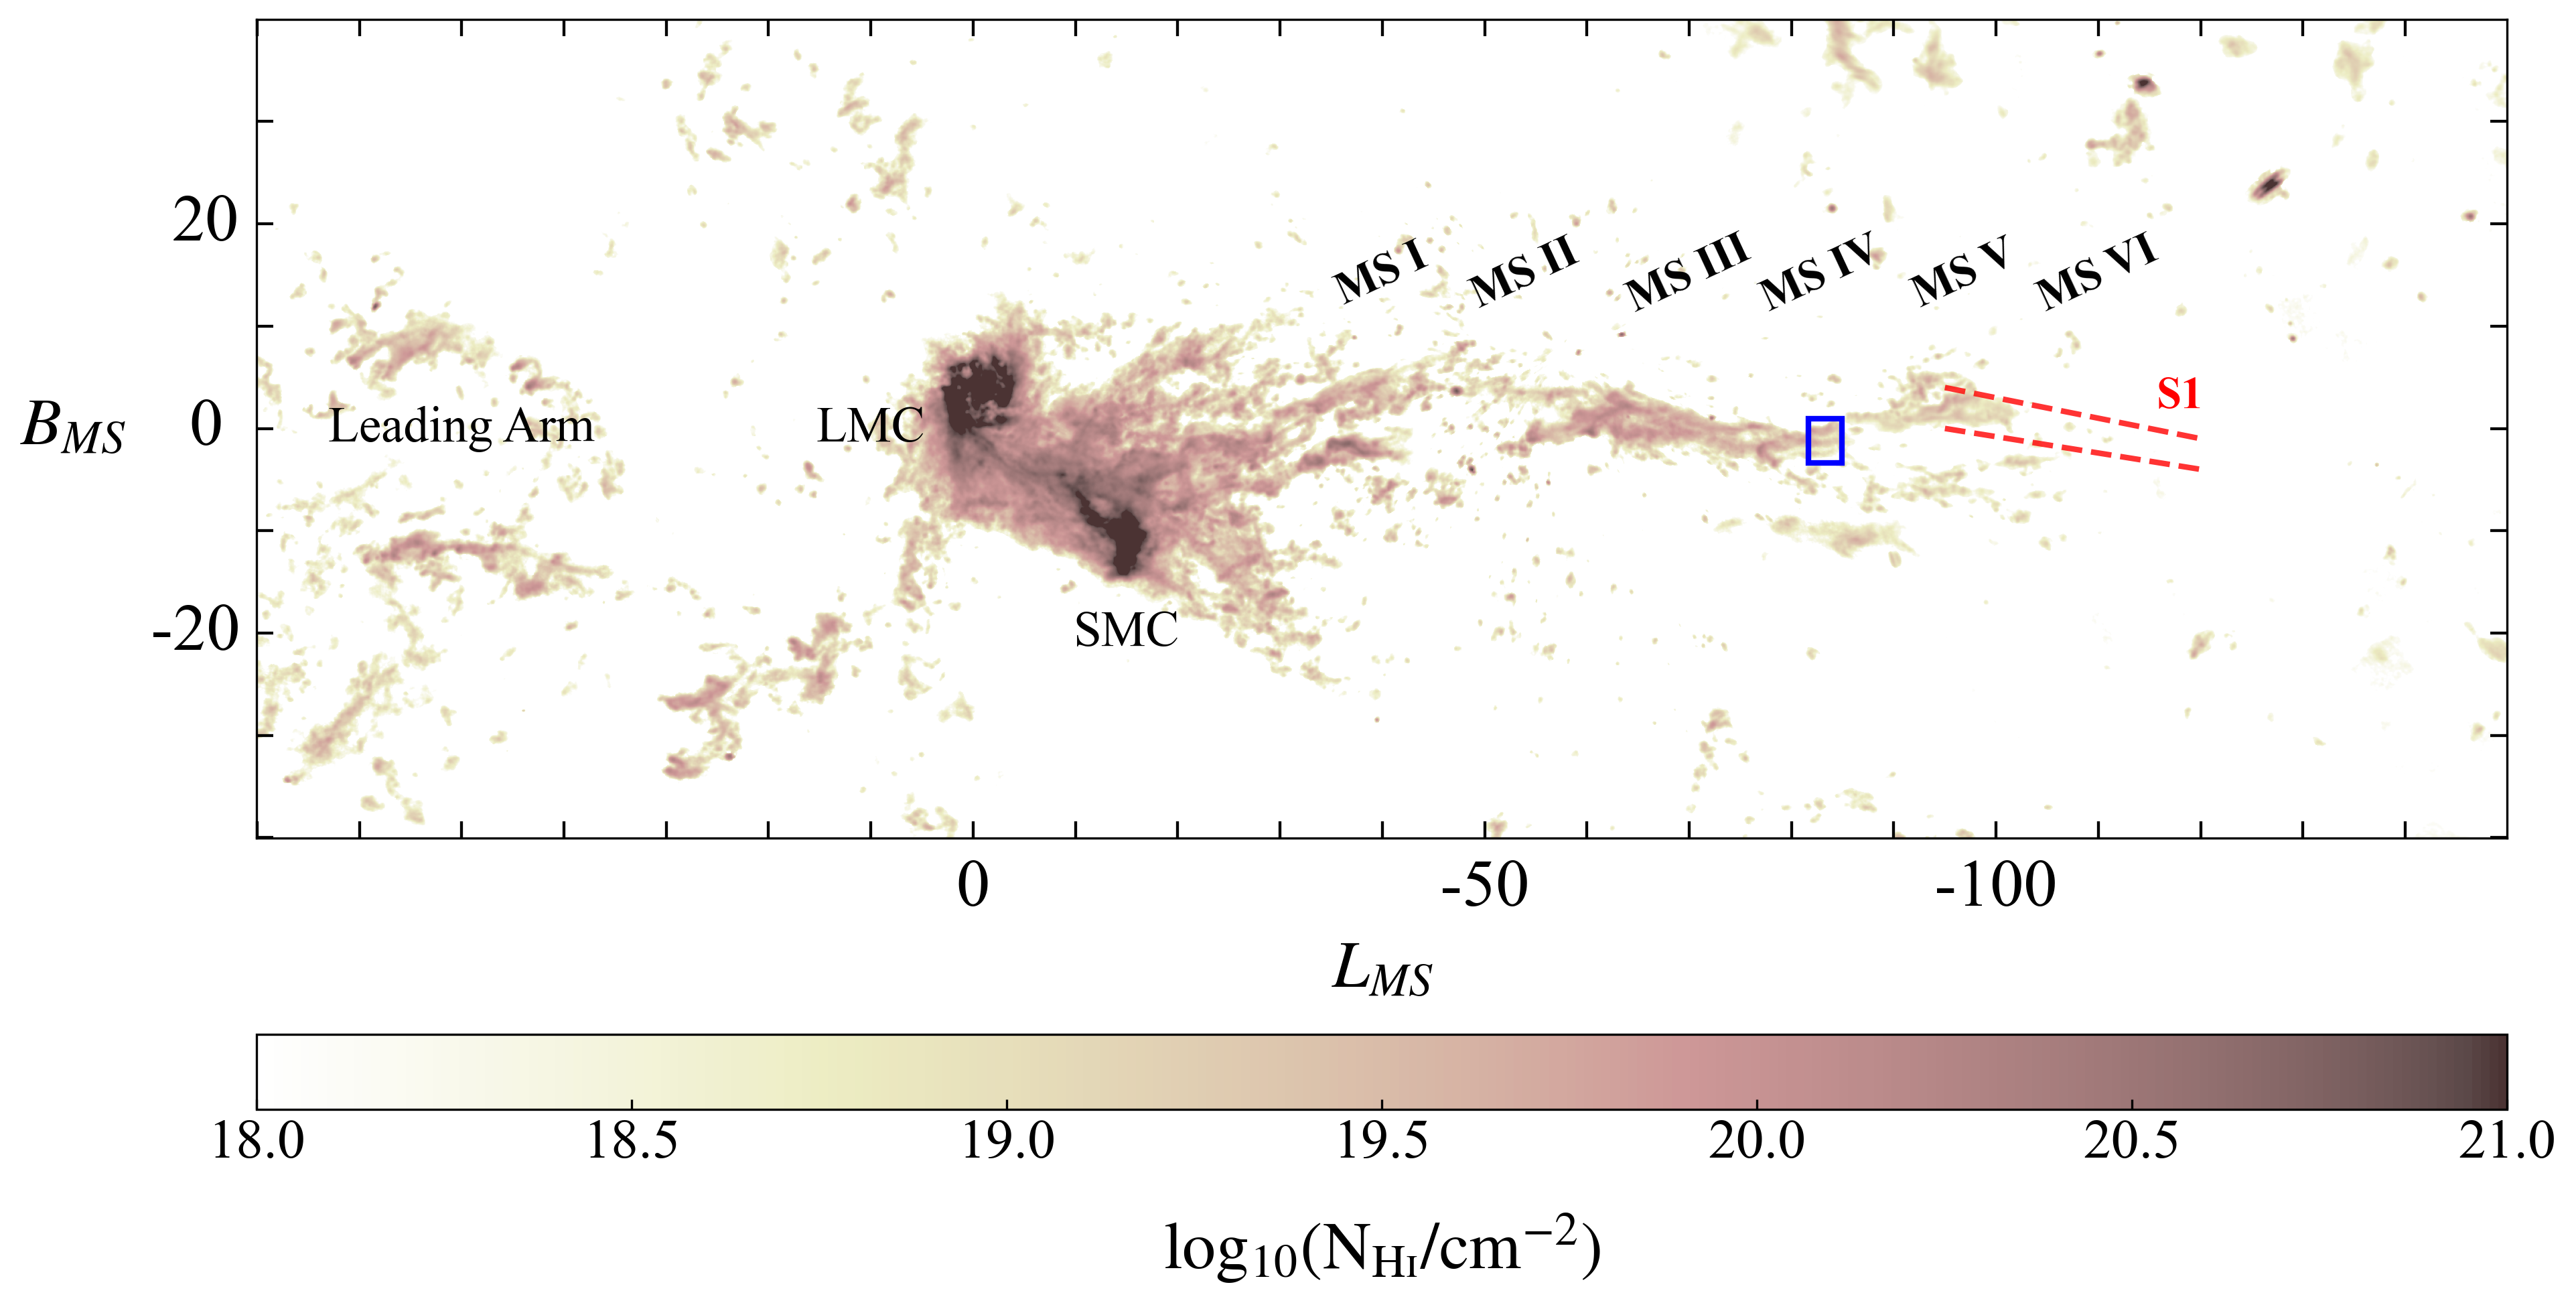

In [48]:
 # 设置全局字体为Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'  # 数学字体也设置为类似Times的STIX字体

# 屏蔽无关警告
warnings.filterwarnings('ignore', category=VerifyWarning)
warnings.filterwarnings('ignore', category=FITSFixedWarning)

# 1. 读取FITS和WCS
hdu = fits.open('D:/Hi/hi4pi-hvc-nhi-mag-car.fits/hi4pi-hvc-nhi-mag-car.fits')[0]
wcs = WCS(hdu.header)

# 2. 定义目标天球范围（银经70°~150°，银纬-40°~40°）
lon_min, lon_max = 70, 210
lat_min, lat_max = -40, 40

# 3. 坐标转换（天球→像素）
coord1 = SkyCoord(lon_min*u.deg, lat_min*u.deg, frame='galactic')
coord2 = SkyCoord(lon_max*u.deg, lat_max*u.deg, frame='galactic')
x1, y1 = wcs.world_to_pixel(coord1)
x2, y2 = wcs.world_to_pixel(coord2)

# 4. 像素索引处理（整数+越界保护）
x_min, x_max = int(np.round(x1)), int(np.round(x2))
y_min, y_max = int(np.round(y1)), int(np.round(y2))
x_min = max(0, x_min)
x_max = min(hdu.data.shape[1], x_max)
y_min = max(0, y_min)
y_max = min(hdu.data.shape[0], y_max)

# 5. 数据+WCS切片
data_slice = hdu.data[y_min:y_max, x_min:x_max]
wcs_slice = wcs.slice((slice(y_min, y_max), slice(x_min, x_max)))

# -------------------------- 绘图核心修改 --------------------------
# -------------------------- 绘图核心 --------------------------
fig = plt.figure(figsize=(16,10), dpi=300)
ax = fig.add_subplot(111, projection=wcs_slice)
im = ax.imshow(data_slice,cmap='pink_r', origin='lower', vmin=18, vmax=21, alpha=0.8)

# 网格/刻度/标签（你原来的代码）
ax.coords.grid(False)
ax.coords['GLON-CAR'].set_ticks(spacing=10 * u.deg)
ax.coords['GLAT-CAR'].set_ticks(spacing=10 * u.deg)
ax.coords['GLON-CAR'].set_ticklabel_visible(False)
ax.coords['GLAT-CAR'].set_ticklabel_visible(False)
ax.tick_params(axis='both', which='both', direction='in', length=6, width=1, color='black')
ax.coords['GLON-CAR'].set_axislabel(r'$L_{MS}$', size=18)
ax.coords['GLAT-CAR'].set_axislabel(r'$B_{MS}$', size=18)

# -------------------------- 标注 LMC / SMC / MS / LA --------------------------
labels = [
    (50, 0, 'Leading Arm', 'black'),
    (10, 0, 'LMC', 'black'),
    (345, -20, 'SMC', 'black')
]
for glon, glat, label, color in labels:
    ax.text(
        glon, glat, label,
        color=color, fontsize=18, ha='center', va='center',
        transform=ax.get_transform('world')
    )
labels = [

    (320,-53, r'$L_{MS}$','black' ),
    (88,0, r'$B_{MS}$','black' ),
    (360,-45, '0','black' ),
    (310,-45, '-50','black' ),
    (260,-45, '-100','black' ),
    (75,0, '0','black' ),
    (75,20, '20','black' ),
    (76,-20, '-20','black' ),
]
for glon, glat, label, color in labels:
    ax.text(
        glon, glat, label,
        color=color, fontsize=24, ha='center', va='center',
        transform=ax.get_transform('world')
    )


# 格式：(GLON, GLAT, 文字, 颜色, 旋转角度rotation, 字号)
ms_labels = [
    # MS I–VI 沿流线分布，角度约 -10°~-20°（顺时针倾斜）
    (320, 15, 'MS I',   'black', 25, 16),
    (306, 15, 'MS II',  'black', 25, 16),
    (290, 15, 'MS III', 'black', 25, 16),
    (277,  15, 'MS IV',  'black', 25, 16),
    (263,  15, 'MS V',   'black', 25, 16),
    (250,  15, 'MS VI',  'black', 25, 16),
    (242,  3, 'S1',  'red', 0, 16),
]

for glon, glat, label, color, rot, fs in ms_labels:
    ax.text(
        glon, glat, label,
        color=color,
        fontsize=fs,
        ha='center', va='center',  # 文字中心对准点
        rotation=rot,              # 倾斜角度（关键）
        rotation_mode='anchor',    # 以锚点为中心旋转（更稳）
        weight='bold',             # 加粗（可选，匹配原图）
        transform=ax.get_transform('world')  # 天球坐标定位
    )


start1_lon, start1_lat = 265, 4     # -100° → 260°
end1_lon, end1_lat =  240, -1      # -120° → 240°

start1_coord = SkyCoord(start1_lon*u.deg, start1_lat*u.deg, frame='galactic')
end1_coord = SkyCoord(end1_lon*u.deg, end1_lat*u.deg, frame='galactic')
x1_start, y1_start = wcs_slice.world_to_pixel(start1_coord)
x1_end, y1_end = wcs_slice.world_to_pixel(end1_coord)

ax.plot(
    [x1_start, x1_end], [y1_start, y1_end],
    linestyle='--',
    color='red',
    linewidth=2,
    zorder=10,
    alpha=0.8
)


start2_lon, start2_lat = 265, 0    # -80° → 280°
end2_lon, end2_lat = 240, -4      # -100° → 260°

start2_coord = SkyCoord(start2_lon*u.deg, start2_lat*u.deg, frame='galactic')
end2_coord = SkyCoord(end2_lon*u.deg, end2_lat*u.deg, frame='galactic')
x2_start, y2_start = wcs_slice.world_to_pixel(start2_coord)
x2_end, y2_end = wcs_slice.world_to_pixel(end2_coord)

ax.plot(
    [x2_start, x2_end], [y2_start, y2_end],
    linestyle='--',
    color='red',
    linewidth=2,
    zorder=10,
    alpha=0.8
)


    
# 色条（你原来的代码）
cbar = plt.colorbar(im, shrink=1, location='bottom', aspect=30, alpha=0.6)
cbar.set_label(
    r'$\mathrm{log}_{10}(\mathrm{N}_{\mathrm{Hɪ}}/\mathrm{cm}^{-2})$',
    size=24,
    labelpad=15
)
cbar.ax.tick_params(labelsize=20, direction='in')



# 布局（注释 tight_layout，避免裁标签）
plt.subplots_adjust(bottom=0.3, left=0.25, right=0.95, top=0.95)
# 1. 定义方框的银经/银纬范围（[min, max]）
lon_range = [275.07, 278.34]  # 银经GLON范围
lat_range = [-3.39, 0.96]     # 银纬GLAT范围

# lon_range = [274, 279.5]  # 银经GLON范围
# lat_range = [-6.2, 4]     # 银纬GLAT范围


# 2. 将经纬度（度数）转换为图像像素坐标（关键：用WCS的world_to_pixel）
# 定义方框四个角的天球坐标
corner1 = SkyCoord(lon_range[0]*u.deg, lat_range[0]*u.deg, frame='galactic')  # 左下角
corner2 = SkyCoord(lon_range[1]*u.deg, lat_range[1]*u.deg, frame='galactic')  # 右上角

# 转换为像素坐标（x=银经，y=银纬）
x1, y1 = wcs_slice.world_to_pixel(corner1)
x2, y2 = wcs_slice.world_to_pixel(corner2)

# 3. 计算方框的起点、宽度、高度（适配Rectangle参数）
x_start = min(x1, x2)       # 左下角x
y_start = min(y1, y2)       # 左下角y
width = abs(x2 - x1)        # 方框宽度
height = abs(y2 - y1)       # 方框高度

# 4. 创建并添加方框（样式可自定义）
rect = patches.Rectangle(
    (x_start, y_start),  # 左下角像素坐标
    width, height,       # 宽、高
    edgecolor='blue',    # 边框颜色（蓝色）
    facecolor='none',    # 填充色（透明，避免遮挡图像）
    linewidth=2,         # 边框线宽
    linestyle='-',       # 线型（实线）
    zorder=5             # 层级（确保在图像上方、标注下方）
)
ax.add_patch(rect)
# plt.savefig('D:/MS/cut/photo/CRAFTS-magellanic.pdf', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
绘制moment map

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

import astropy.units as u
from astropy.utils.data import download_file
from astropy.io import fits  # We use fits to open the actual data file

from astropy.utils import data

data.conf.remote_timeout = 60


from spectral_cube import SpectralCube
 
#from astroquery.esasky import ESASky
#from astroquery.utils import TableList
from astropy.wcs import WCS
from reproject import reproject_interp

from matplotlib.pyplot import MultipleLocator
import matplotlib.patches as patches
from matplotlib import gridspec

In [2]:
#hi_data = fits.open('all.fits')[0]  # Open the F00_DEC_-13.0_-3.0__34_RA_340.0_350.0__-100kms_-30kms.I.fitsITS file for reading
cube = SpectralCube.read('./cut/new_baseline/CRAFTS_4.5/CRAFTS_-4.7_-350_-150_baseline_Jy_mask----mask-K.fits')  # Initiate a SpectralCube
#hi_data.close()  # Close the FITS file - we already read it in and don't need it anymore!
print(cube)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: m / s  range:  -349902.947 m / s: -150028.338 m / s


In [3]:
x_range = [356.8, 352.9] * u.deg
y_range = [-6.89, -4.69] * u.deg
# Create a sub_cube cut to these coordinates
sub_cube = cube.subcube(
    xlo=x_range[0], xhi=x_range[1],
    ylo=y_range[0], yhi=y_range[1],)

print(sub_cube)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: m / s  range:  -349902.947 m / s: -150028.338 m / s


In [4]:
sub_cube_slab = cube.spectral_slab(-350*u.km / u.s,  -150*u.km / u.s)
print(sub_cube_slab)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: m / s  range:  -349902.947 m / s: -150028.338 m / s


In [5]:
#hi_data = fits.open('all.fits')[0]  # Open the F00_DEC_-13.0_-3.0__34_RA_340.0_350.0__-100kms_-30kms.I.fitsITS file for reading
cube_H = SpectralCube.read('./cut/new_baseline/HI4PI_4.5/HI4PI_-4.7_-350_-150_baseline_Jy_mask----mask-K.fits')  # Initiate a SpectralCube
#hi_data.close()  # Close the FITS file - we already read it in and don't need it anymore!
print(cube_H)

SpectralCube with shape=(156, 28, 47) and unit=K:
 n_x:     47  type_x: RA---CAR  unit_x: deg    range:   353.000000 deg:  356.833333 deg
 n_y:     28  type_y: DEC--CAR  unit_y: deg    range:    -6.916667 deg:   -4.666667 deg
 n_s:    156  type_s: VRAD      unit_s: m / s  range:  -350293.514 m / s: -150620.194 m / s


In [6]:
x_range = [356.8, 352.8] * u.deg
y_range = [-6.892663, -4.69] * u.deg
# Create a sub_cube cut to these coordinates
sub_cube_H = cube_H.subcube(
    xlo=x_range[0], xhi=x_range[1],
    ylo=y_range[0], yhi=y_range[1],)
print(sub_cube_H)

SpectralCube with shape=(156, 28, 47) and unit=K:
 n_x:     47  type_x: RA---CAR  unit_x: deg    range:   353.000000 deg:  356.833333 deg
 n_y:     28  type_y: DEC--CAR  unit_y: deg    range:    -6.916667 deg:   -4.666667 deg
 n_s:    156  type_s: VRAD      unit_s: m / s  range:  -350293.514 m / s: -150620.194 m / s


In [7]:
sub_cube_slab_H=cube_H.spectral_slab(-350*u.km / u.s,  -150*u.km / u.s)
print(sub_cube_slab)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: m / s  range:  -349902.947 m / s: -150028.338 m / s


In [8]:
moment_0 = sub_cube_slab.with_spectral_unit(u.km/u.s).moment(order=0)  # Zero-th moment 
moment_1 = sub_cube_slab.with_spectral_unit(u.km/u.s).moment(order=1)  # First moment
moment_2 = sub_cube_slab.with_spectral_unit(u.km/u.s).linewidth_fwhm()# moment(order=2)
#   # First moment

# Write the moments as a FITS image
# moment_0.write('hi_moment_0.fits') 
# moment_1.write('hi_moment_1.fits')

print('Moment_0 has units of: ', moment_0.unit)
print('Moment_1 has units of: ', moment_1.unit)
# print('hi_column_density has units of: ', hi_column_density.unit)
# Convert Moment_0 to a Column Density assuming optically thin media
hi_column_density = moment_0 * 1.82 * 10**18 / (u.cm * u.cm) * u.s / u.Jy/u.beam / u.km

D:\Miniconda3\Lib\site-packages\spectral_cube\_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


Moment_0 has units of:  K km / s
Moment_1 has units of:  km / s


In [9]:
moment_0_H = sub_cube_slab_H.with_spectral_unit(u.km/u.s).moment(order=0)  # Zero-th moment 
moment_1_H = sub_cube_slab_H.with_spectral_unit(u.km/u.s).moment(order=1)  # First moment
moment_2_H = sub_cube_slab_H.with_spectral_unit(u.km/u.s).linewidth_fwhm()# moment(order=2)
#   # First moment

# Write the moments as a FITS image
# moment_0.write('hi_moment_0.fits') 
# moment_1.write('hi_moment_1.fits')

print('Moment_0 has units of: ', moment_0_H.unit)
print('Moment_1 has units of: ', moment_1_H.unit)
# print('hi_column_density has units of: ', hi_column_density.unit)
# Convert Moment_0 to a Column Density assuming optically thin media
hi_column_density_H = moment_0_H * 1.82 * 10**18 / (u.cm * u.cm) * u.s / u.Jy/u.beam / u.km


Moment_0 has units of:  K km / s
Moment_1 has units of:  km / s


D:\Miniconda3\Lib\site-packages\spectral_cube\_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


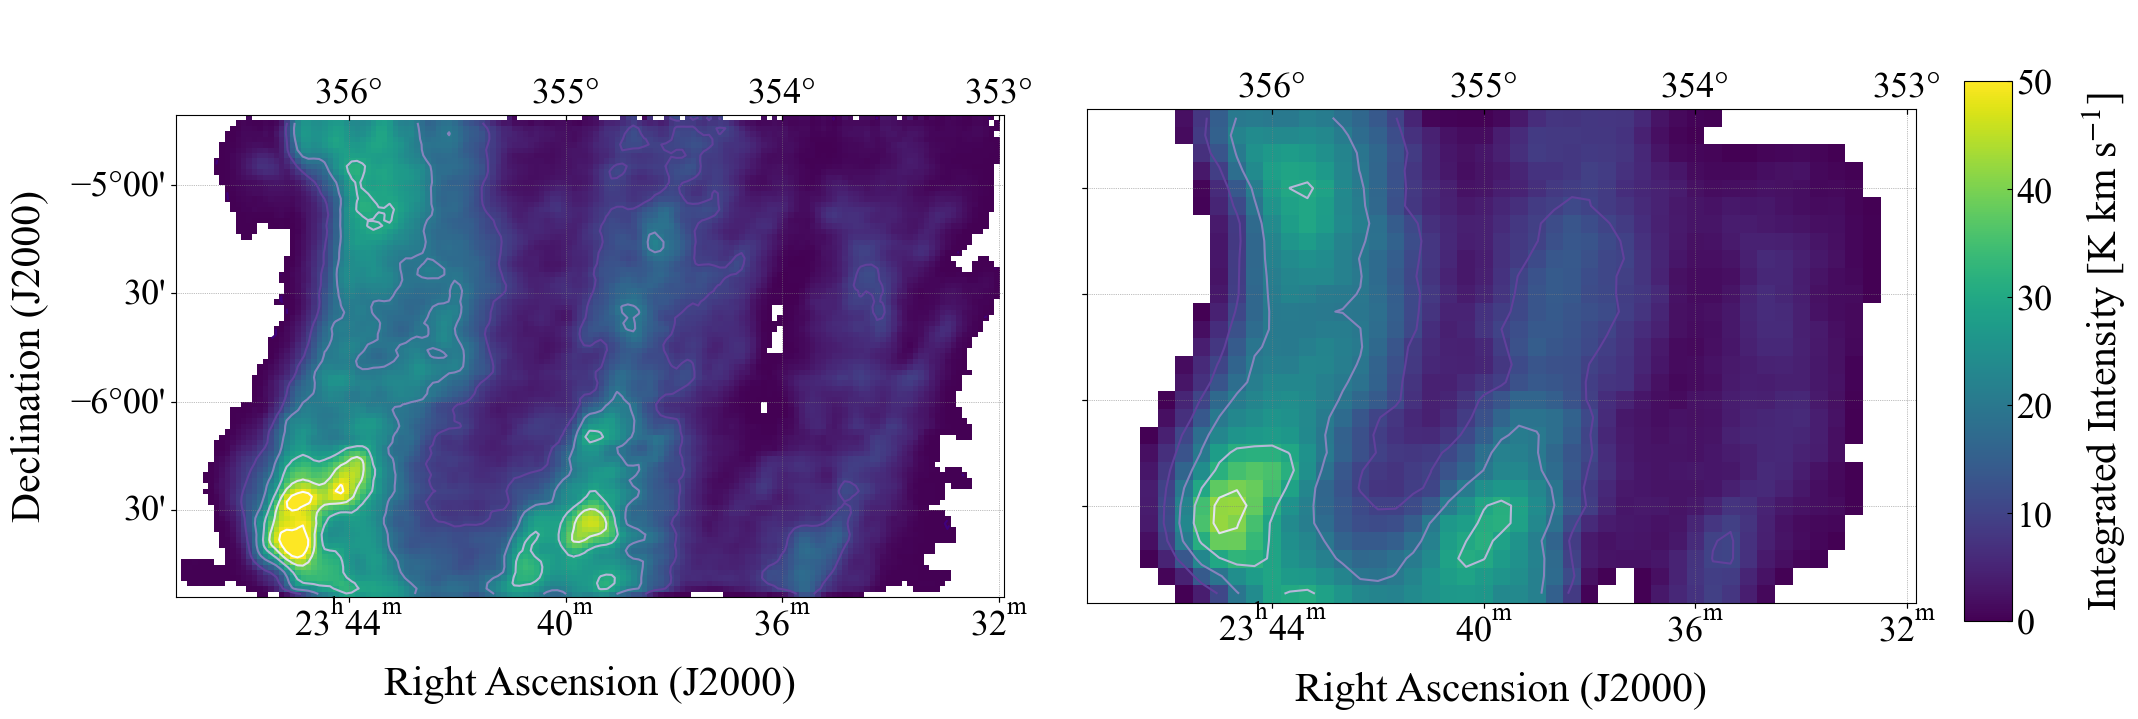

In [10]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'  # 数学字体也设置为类似Times的STIX字体

# 使用GridSpec定义子图布局
fig = plt.figure(figsize=(24, 9))  # 增加宽度以适应两个子图
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.1)

# 创建两个子图，都使用moment_0.wcs投影
ax1 = fig.add_subplot(gs[0], projection=moment_0.wcs)
ax2 = fig.add_subplot(gs[1], projection=moment_0_H.wcs)

# 在两个子图上显示moment map图像
im1 = ax1.imshow(moment_0.hdu.data, cmap='viridis', vmin=0, vmax=50)
im2 = ax2.imshow(moment_0_H.hdu.data, cmap='viridis', vmin=0, vmax=50)

# 配置两个子图的坐标轴
for ax in [ax1, ax2]:
    # 设置坐标轴标签
    ax.set_xlabel("Right Ascension (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.set_ylabel("Declination (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.tick_params(axis='both', which='both', direction='out', labelsize=26)
    
    # 配置WCS坐标轴
    ax.coords[0].set_ticks_position('b')  # RA主刻度显示在下边
    ax.coords[1].set_ticks_position('l')  # Dec主刻度显示在左边
    
    # 设置主坐标轴格式：RA显示为小时，Dec显示为度
    ax.coords[0].set_format_unit(u.hourangle)  # 设置RA单位为小时
    ax.coords[1].set_format_unit(u.deg)        # 设置Dec单位为度
    
    # 创建上侧的RA角度副坐标轴
    overlay_ra_deg = ax.get_coords_overlay('fk5')
    overlay_ra_deg[0].set_axislabel(' ', fontsize=30, fontname='Times New Roman', minpad=1)
    overlay_ra_deg[0].tick_params(labelsize=26, direction='in')
    overlay_ra_deg[0].set_ticks_position('t')  # 显示在上边
    overlay_ra_deg[0].set_format_unit(u.deg)   # 显示为角度
    
    # 隐藏不需要的坐标轴
    overlay_ra_deg[1].set_axislabel('')
    overlay_ra_deg[1].set_ticklabel_visible(False)
    overlay_ra_deg[1].set_ticks_visible(False)
    overlay_ra_deg.grid(color='grey', ls='dotted', lw=0.5)
    

# 为第二个子图隐藏Y轴标签和刻度（避免与第一个子图重复）
ax2.set_ylabel('')  # 隐藏Y轴标签
ax2.coords[1].set_ticklabel_visible(False)  # 隐藏Y轴刻度标签
ax2.coords[1].set_ticks_visible(True)  # 保留刻度线
ax2.tick_params(axis='y', which='both', labelleft=False)  # 隐藏左侧刻度标签

contour1 = ax1.contour(moment_0.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
contour2 = ax2.contour(moment_0_H.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
# 添加一个统一的颜色条在最右侧
# 为颜色条预留空间：调整子图位置
fig.subplots_adjust(right=0.85)  # 为右侧颜色条留出空间

# 创建颜色条轴
cbar_ax = fig.add_axes([0.87, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label('Integrated Intensity [K km s$^{-1}$]', size=30, labelpad=20)
cbar.ax.tick_params(labelsize=26, direction='in')

# 保存图片
# plt.savefig('./cut/photo/CRAFTS+HI4PI_0.pdf', dpi=300, bbox_inches='tight')

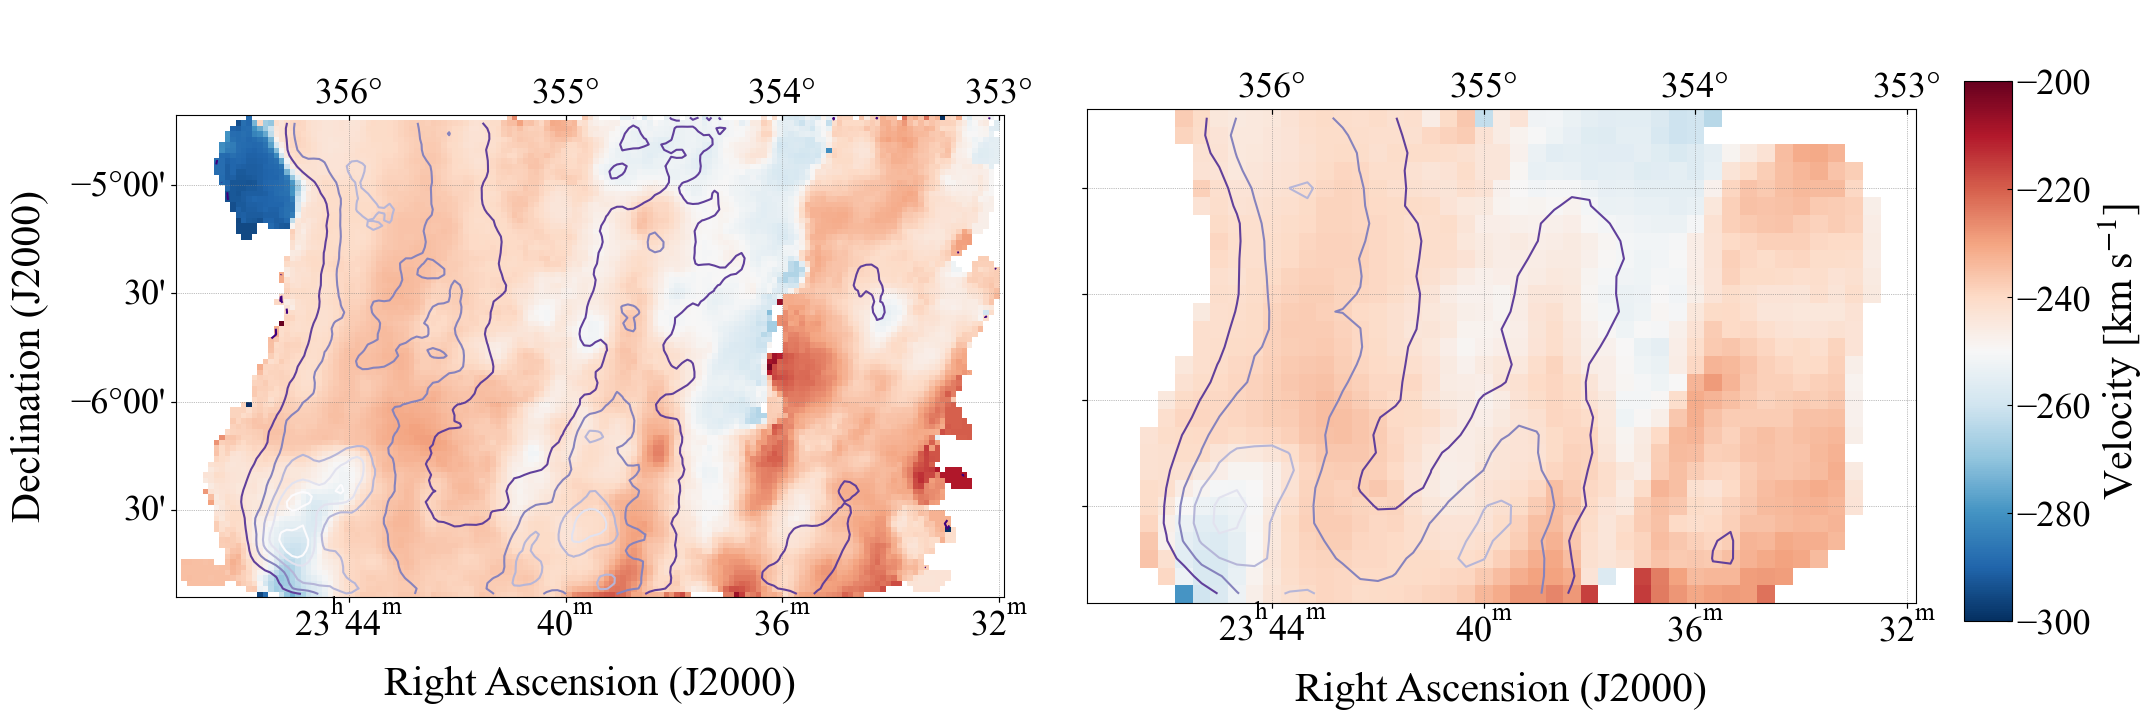

In [11]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'  # 数学字体也设置为类似Times的STIX字体

# 使用GridSpec定义子图布局
fig = plt.figure(figsize=(24, 9))  # 增加宽度以适应两个子图
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.1)

# 创建两个子图，都使用moment_0.wcs投影
ax1 = fig.add_subplot(gs[0], projection=moment_0.wcs)
ax2 = fig.add_subplot(gs[1], projection=moment_0_H.wcs)

# 在两个子图上显示moment map图像
im1 = ax1.imshow(moment_1.hdu.data, cmap='RdBu_r', vmin=-300, vmax=-200)
im2 = ax2.imshow(moment_1_H.hdu.data, cmap='RdBu_r', vmin=-300, vmax=-200)

# 配置两个子图的坐标轴
for ax in [ax1, ax2]:
    # 设置坐标轴标签
    ax.set_xlabel("Right Ascension (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.set_ylabel("Declination (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.tick_params(axis='both', which='both', direction='out', labelsize=26)
    
    # 配置WCS坐标轴
    ax.coords[0].set_ticks_position('b')  # RA主刻度显示在下边
    ax.coords[1].set_ticks_position('l')  # Dec主刻度显示在左边
    
    # 设置主坐标轴格式：RA显示为小时，Dec显示为度
    ax.coords[0].set_format_unit(u.hourangle)  # 设置RA单位为小时
    ax.coords[1].set_format_unit(u.deg)        # 设置Dec单位为度
    
    # 创建上侧的RA角度副坐标轴
    overlay_ra_deg = ax.get_coords_overlay('fk5')
    overlay_ra_deg[0].set_axislabel(' ', fontsize=30, fontname='Times New Roman', minpad=1)
    overlay_ra_deg[0].tick_params(labelsize=26, direction='in')
    overlay_ra_deg[0].set_ticks_position('t')  # 显示在上边
    overlay_ra_deg[0].set_format_unit(u.deg)   # 显示为角度
    
    # 隐藏不需要的坐标轴
    overlay_ra_deg[1].set_axislabel('')
    overlay_ra_deg[1].set_ticklabel_visible(False)
    overlay_ra_deg[1].set_ticks_visible(False)
    overlay_ra_deg.grid(color='grey', ls='dotted', lw=0.5)
    

# 为第二个子图隐藏Y轴标签和刻度（避免与第一个子图重复）
ax2.set_ylabel('')  # 隐藏Y轴标签
ax2.coords[1].set_ticklabel_visible(False)  # 隐藏Y轴刻度标签
ax2.coords[1].set_ticks_visible(True)  # 保留刻度线
ax2.tick_params(axis='y', which='both', labelleft=False)  # 隐藏左侧刻度标签

contour1 = ax1.contour(moment_0.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
contour2 = ax2.contour(moment_0_H.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
# 添加一个统一的颜色条在最右侧
# 为颜色条预留空间：调整子图位置
fig.subplots_adjust(right=0.85)  # 为右侧颜色条留出空间

# 创建颜色条轴
cbar_ax = fig.add_axes([0.87, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label('Velocity [km s$^{-1}$]', size=30)
cbar.ax.tick_params(labelsize=26, direction='in')

# 保存图片
# plt.savefig('./cut/photo/CRAFTS+HI4PI_1.pdf', dpi=300, bbox_inches='tight')

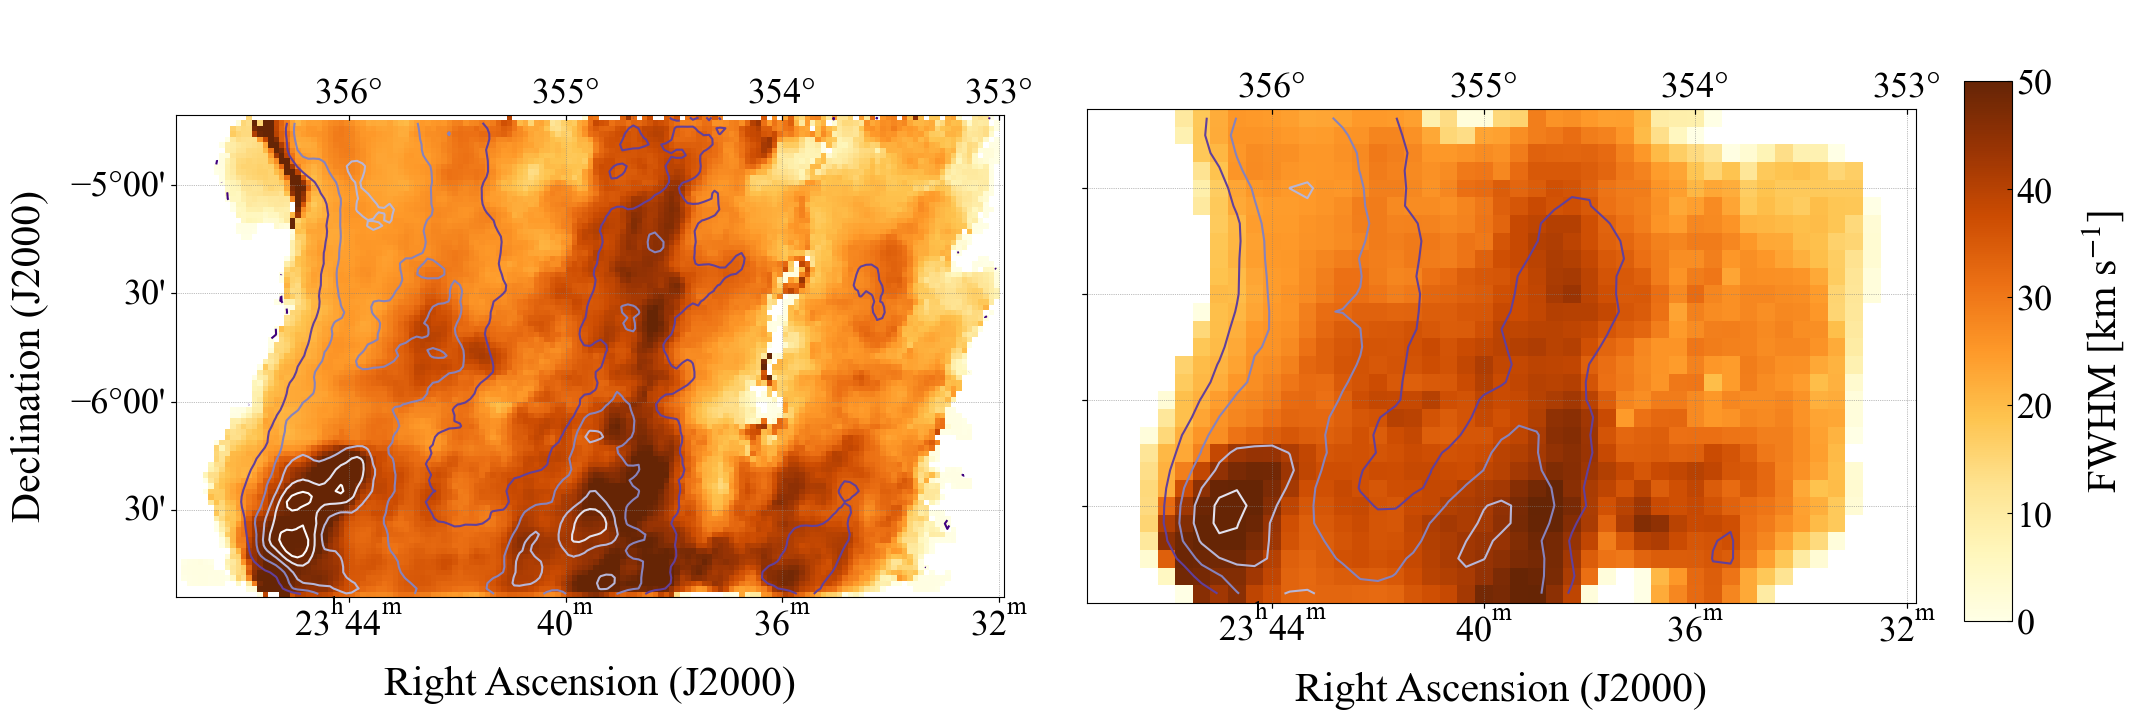

In [12]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'  # 数学字体也设置为类似Times的STIX字体

# 使用GridSpec定义子图布局
fig = plt.figure(figsize=(24, 9))  # 增加宽度以适应两个子图
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.1)

# 创建两个子图，都使用moment_0.wcs投影
ax1 = fig.add_subplot(gs[0], projection=moment_0.wcs)
ax2 = fig.add_subplot(gs[1], projection=moment_0_H.wcs)

# 在两个子图上显示moment map图像
im1 = ax1.imshow(moment_2.hdu.data, cmap='YlOrBr', vmin=0, vmax=50)
im2 = ax2.imshow(moment_2_H.hdu.data, cmap='YlOrBr', vmin=0, vmax=50)

# 配置两个子图的坐标轴
for ax in [ax1, ax2]:
    # 设置坐标轴标签
    ax.set_xlabel("Right Ascension (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.set_ylabel("Declination (J2000)", fontsize=30, fontname='Times New Roman', labelpad=1)
    ax.tick_params(axis='both', which='both', direction='out', labelsize=26)
    
    # 配置WCS坐标轴
    ax.coords[0].set_ticks_position('b')  # RA主刻度显示在下边
    ax.coords[1].set_ticks_position('l')  # Dec主刻度显示在左边
    
    # 设置主坐标轴格式：RA显示为小时，Dec显示为度
    ax.coords[0].set_format_unit(u.hourangle)  # 设置RA单位为小时
    ax.coords[1].set_format_unit(u.deg)        # 设置Dec单位为度
    
    # 创建上侧的RA角度副坐标轴
    overlay_ra_deg = ax.get_coords_overlay('fk5')
    overlay_ra_deg[0].set_axislabel(' ', fontsize=30, fontname='Times New Roman', minpad=1)
    overlay_ra_deg[0].tick_params(labelsize=26, direction='in')
    overlay_ra_deg[0].set_ticks_position('t')  # 显示在上边
    overlay_ra_deg[0].set_format_unit(u.deg)   # 显示为角度
    
    # 隐藏不需要的坐标轴
    overlay_ra_deg[1].set_axislabel('')
    overlay_ra_deg[1].set_ticklabel_visible(False)
    overlay_ra_deg[1].set_ticks_visible(False)
    overlay_ra_deg.grid(color='grey', ls='dotted', lw=0.5)
    

# 为第二个子图隐藏Y轴标签和刻度（避免与第一个子图重复）
ax2.set_ylabel('')  # 隐藏Y轴标签
ax2.coords[1].set_ticklabel_visible(False)  # 隐藏Y轴刻度标签
ax2.coords[1].set_ticks_visible(True)  # 保留刻度线
ax2.tick_params(axis='y', which='both', labelleft=False)  # 隐藏左侧刻度标签

contour1 = ax1.contour(moment_0.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
contour2 = ax2.contour(moment_0_H.hdu.data, cmap='Purples_r', alpha=1,linewidths=1.5, levels=[0,10,20,30,40,50])
# 添加一个统一的颜色条在最右侧
# 为颜色条预留空间：调整子图位置
fig.subplots_adjust(right=0.85)  # 为右侧颜色条留出空间

# 创建颜色条轴
cbar_ax = fig.add_axes([0.87, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label('FWHM [km s$^{-1}$]', size=30, labelpad=20)
cbar.ax.tick_params(labelsize=26, direction='in')

# 保存图片
# plt.savefig('./cut/photo/CRAFTS+HI4PI_2.pdf', dpi=300, bbox_inches='tight')

In [ ]:
绘制PV图

In [24]:
from spectral_cube import SpectralCube
import pylab as pl
from pvextractor import extract_pv_slice, Path
cube = SpectralCube.read('./cut/new_baseline/CRAFTS_4.5/CRAFTS_-4.7_-350_-150_baseline_Jy_mask----mask-K.fits')
cube

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: m / s  range:  -349902.947 m / s: -150028.338 m / s

In [25]:
x_range = [356.8, 352.9] * u.deg
y_range = [-6.89, -4.69] * u.deg
# Create a sub_cube cut to these coordinates
sub_cube = cube.subcube(
    xlo=x_range[0], xhi=x_range[1],
    ylo=y_range[0], yhi=y_range[1],)

print(sub_cube)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: m / s  range:  -349902.947 m / s: -150028.338 m / s


In [31]:
sub_cube_slab = cube.spectral_slab(-350*u.km / u.s,  -150*u.km / u.s)
print(sub_cube_slab)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: m / s  range:  -349902.947 m / s: -150028.338 m / s


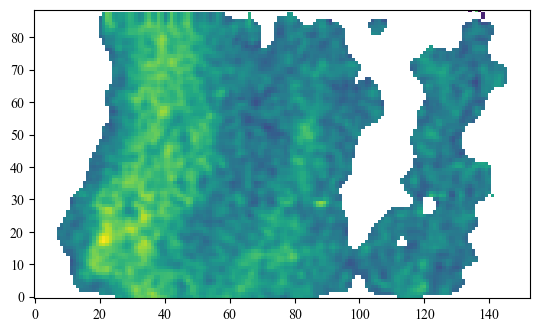

In [40]:
pl.imshow(sub_cube_slab[400].value, origin='lower')

In [41]:
# #X1  100
path1 = Path([(35,0), (39,89)], width=90*u.arcmin)
# #X2  85
path2 = Path([(84,0), (92,89)], width=70*u.arcmin)
##X3   30
path3 = Path([(124,0), (135,89)], width=50*u.arcmin)

D:\Miniconda3\Lib\site-packages\pvextractor\geometry\path.py:262: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches.append(MPLPolygon(list(zip(poly.x, poly.y)), **kwargs))
D:\Miniconda3\Lib\site-packages\pvextractor\geometry\path.py:262: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches.append(MPLPolygon(list(zip(poly.x, poly.y)), **kwargs))
D:\Miniconda3\Lib\site-packages\pvextractor\geometry\path.py:262: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches.append(MPLPolygon(list(zip(poly.x, poly.y)), **kwargs))


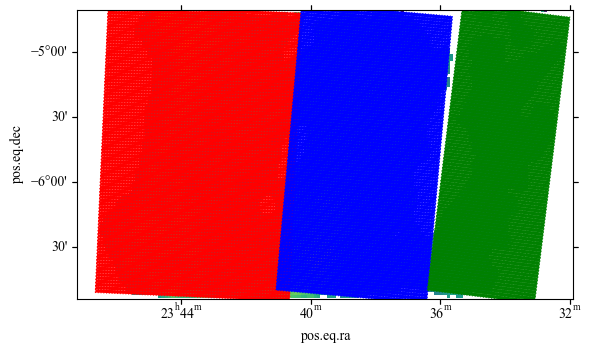

In [42]:
ax = pl.subplot(111, projection=sub_cube_slab.wcs.celestial)
ax.imshow(sub_cube[500].value)
path1.show_on_axis(ax, spacing=1, color='r' ,linestyle=':',
                      linewidth=0.75)
path2.show_on_axis(ax, spacing=1, color='b' ,linestyle=':',
                      linewidth=0.75)
path3.show_on_axis(ax, spacing=1, color='g' ,linestyle=':',
                      linewidth=0.75)

In [49]:
pvdiagram1 = extract_pv_slice(cube=sub_cube_slab, path=path1, spacing=1)
pvdiagram2 = extract_pv_slice(cube=sub_cube_slab, path=path2, spacing=1)
pvdiagram3 = extract_pv_slice(cube=sub_cube_slab, path=path3, spacing=1)

In [50]:
mx = sub_cube_slab.max(axis=0).value

D:\Miniconda3\Lib\site-packages\spectral_cube\spectral_cube.py:440: RuntimeWarning: All-NaN slice encountered
  out = function(self._get_filled_data(fill=fill,


C:\Users\25495\AppData\Local\Temp\ipykernel_40412\3540601360.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


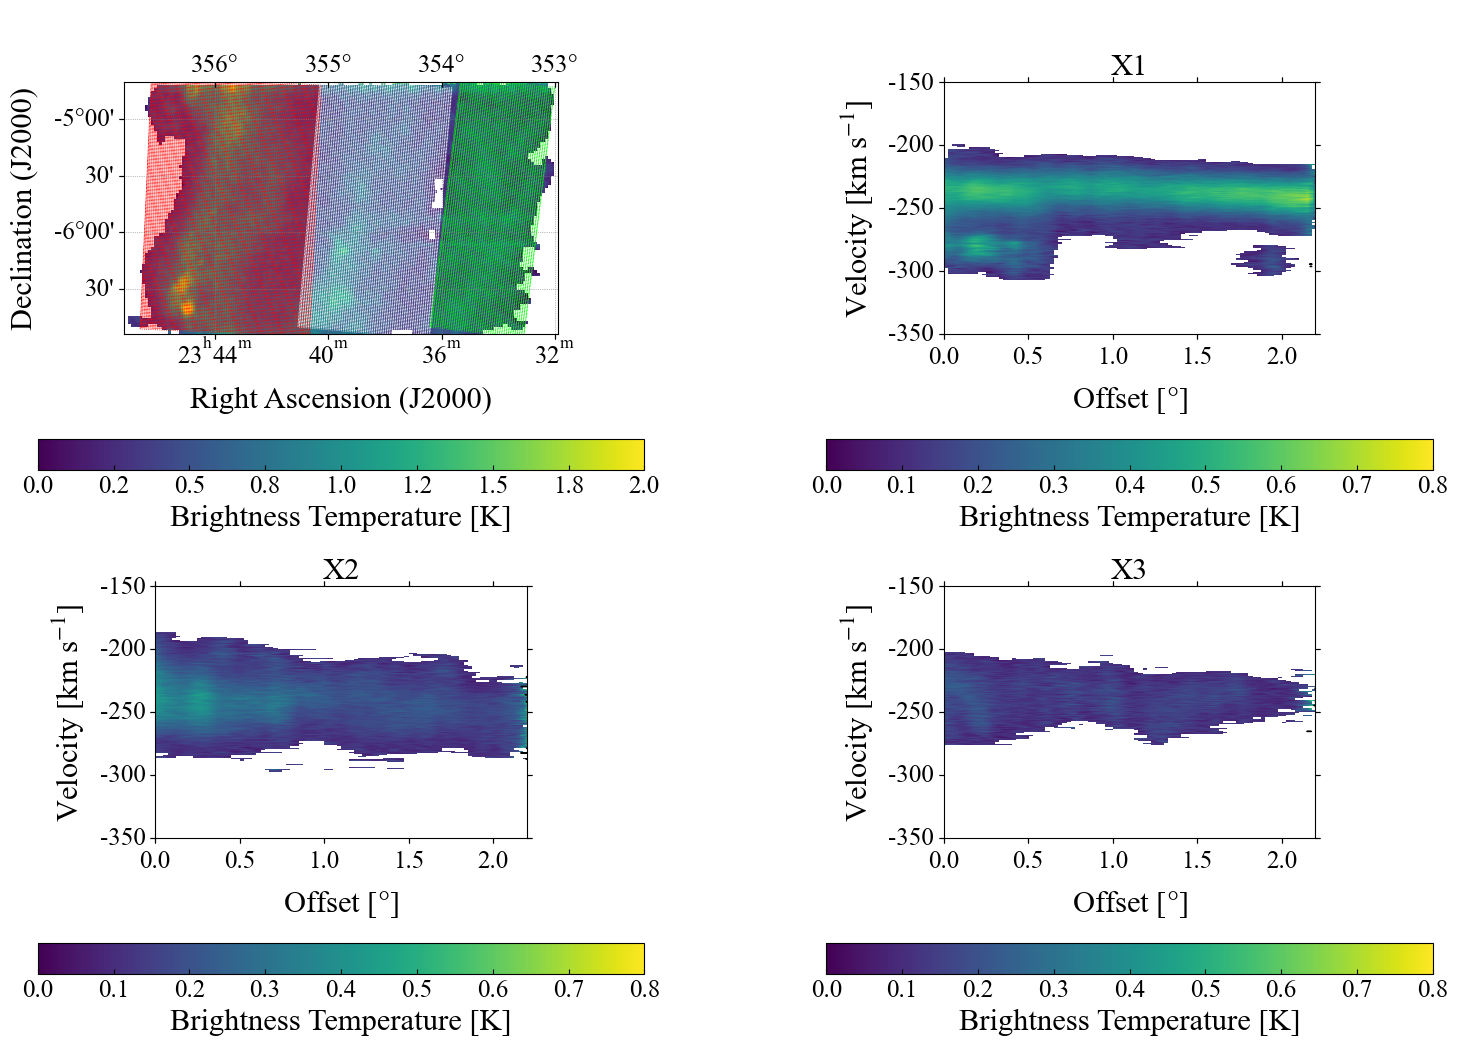

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import astropy.wcs as wcs
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

# 假设以下变量已提前定义（保持你的原始数据逻辑）
# sub_cube: 原始立方体数据
# mx: 原始立方体切片数据（用于第一张总览图）
# path: 标注在总览图上的路径对象
# pvdiagram1/pvdiagram2/pvdiagram3: 三个PV图的数据（带header属性）

# ====================== 1. 初始化画布和布局 ======================
fig = plt.figure(figsize=(18, 12))  # 2×2布局，调整画布高度适配子图
# 定义2×2网格布局，调整间距避免重叠
gs = fig.add_gridspec(2, 2, hspace=0.2, wspace=0.3)

# ====================== 2. 子图1：原始立方体总览图（左上） ======================
ax_original = fig.add_subplot(gs[0, 0], projection=sub_cube_slab.wcs.celestial)
# 绘制原始切片数据，添加origin='lower'保证坐标方向正确
im_original = ax_original.imshow(mx, vmin=0, vmax=2 ,origin='lower')
# ax_original.set_aspect(0.7)
# 标注路径
# path.show_on_axis(ax_original, spacing=1, edgecolor='r', linestyle=':', linewidth=0.75)
path1.show_on_axis(ax_original, spacing=0.5,
                  edgecolor='r', linestyle=':',
                  linewidth=0.6)
path2.show_on_axis(ax_original, spacing=0.5,
                  edgecolor='w', linestyle=':',
                  linewidth=0.6)
path3.show_on_axis(ax_original, spacing=0.5,
                  edgecolor='lime', linestyle=':',
                  linewidth=0.6)



ax_original.set_xlabel("Right Ascension (J2000)", fontsize=22, fontname='Times New Roman', labelpad=1)
ax_original.set_ylabel("Declination (J2000)", fontsize=22, fontname='Times New Roman', labelpad=1)
ax_original.tick_params(axis='both', which='both', direction='out', labelsize=18)

# 配置WCS坐标轴
ax_original.coords[0].set_ticks_position('b')  # RA主刻度显示在下边
ax_original.coords[1].set_ticks_position('l')  # Dec主刻度显示在左边

# 设置主坐标轴格式：RA显示为小时，Dec显示为度
ax_original.coords[0].set_format_unit(u.hourangle)  # 设置RA单位为小时
ax_original.coords[1].set_format_unit(u.deg)       # 设置Dec单位为度

# 创建上侧的RA角度副坐标轴
overlay1_ra_deg = ax_original.get_coords_overlay('fk5')
overlay1_ra_deg[0].set_axislabel(' ', fontsize=22, fontname='Times New Roman', minpad=1)
overlay1_ra_deg[0].tick_params(labelsize=18, direction='in')
overlay1_ra_deg[0].set_ticks_position('t')  # 显示在上边
overlay1_ra_deg[0].set_format_unit(u.deg)  # 显示为角度

# 隐藏不需要的坐标轴
overlay1_ra_deg[1].set_axislabel('')
overlay1_ra_deg[1].set_ticklabel_visible(False)
overlay1_ra_deg[1].set_ticks_visible(False)
overlay1_ra_deg.grid(color='grey', ls='dotted', lw=0.5)

# 为原始图添加颜色条（统一单位为K）
cb_original = fig.colorbar(im_original, ax=ax_original, pad=.25,location = 'bottom')
cb_original.set_label("Brightness Temperature [K]", size=22)
cb_original.ax.tick_params(labelsize=18, direction='in')
cb_original.ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
# ====================== 3. 子图2：PV图1（右上） ======================
# 读取PV图1的WCS
wcs_pv1 = wcs.WCS(pvdiagram1.header)
ax_pv1 = fig.add_subplot(gs[0, 1], projection=wcs_pv1)
im_pv1 = ax_pv1.imshow(pvdiagram1.data, origin='lower', vmin=0, vmax=0.8)
ax_pv1.set_aspect(0.06)

# 处理PV图1的NaN数据（仅用当前PV图数据，修正原错误引用）
data_pv1 = pvdiagram1.data.copy()
if np.isnan(data_pv1).any():
    data_pv1 = np.nan_to_num(data_pv1, nan=0)

# 设置坐标轴单位和刻度
deg_min = 0.0  # 最小角度
deg_max = 2.2  # 最大角度

# 方法1.1：使用wcs的all_world2pix方法
world_coords_min = [[deg_min, 0]]  # [offset, velocity]，velocity可以是任意值
world_coords_max = [[deg_max, 0]]
pixel_coords_min = wcs_pv1.all_world2pix(world_coords_min, 0)
pixel_coords_max = wcs_pv1.all_world2pix(world_coords_max, 0)

# 设置像素坐标范围
ax_pv1.set_xlim(pixel_coords_min[0][0], pixel_coords_max[0][0])

coord_pv1_x = ax_pv1.coords[0]
coord_pv1_x.set_format_unit(u.deg)
coord_pv1_x.tick_params(axis='both', which='both', direction='out', labelsize=18)


coord_pv1_y = ax_pv1.coords[1]
coord_pv1_y.set_format_unit(u.km / u.s)
coord_pv1_y.tick_params(axis='both', which='both', direction='out', labelsize=18)

# 添加颜色条
cb_pv1 = fig.colorbar(im_pv1, ax=ax_pv1, pad=.25,location = 'bottom')
cb_pv1.set_label("Brightness Temperature [K]", size=22)
cb_pv1.ax.tick_params(labelsize=18, direction='in')

# 绘制等高线（使用PV图1的正确数据）
contour_pv1 = ax_pv1.contour(data_pv1, levels=[1.0, 1.4, 1.8], colors='black', linewidths=1)
ax_pv1.clabel(contour_pv1, inline=True, fontsize=18)

# 设置标签和标题
ax_pv1.set_ylabel("Velocity [km s$^{-1}$]", fontsize=22)
ax_pv1.set_xlabel("Offset [$°$]", fontsize=22)
ax_pv1.set_title("X1", fontsize=22)
ax_pv1.invert_yaxis()
# ====================== 4. 子图3：PV图2（左下） ======================
# 读取PV图2的WCS（修正原重复命名ww2的问题）
wcs_pv2 = wcs.WCS(pvdiagram2.header)
ax_pv2 = fig.add_subplot(gs[1, 0], projection=wcs_pv2)
im_pv2 = ax_pv2.imshow(pvdiagram2.data, origin='lower', vmin=0, vmax=0.8)
ax_pv2.set_aspect(0.06)

# 处理PV图2的NaN数据（修正原错误引用pvdiagram1的问题）
data_pv2 = pvdiagram2.data.copy()
if np.isnan(data_pv2).any():
    data_pv2 = np.nan_to_num(data_pv2, nan=0)

ax_pv2.set_xlim(pixel_coords_min[0][0], pixel_coords_max[0][0])
# 设置坐标轴单位和刻度
coord_pv2_x = ax_pv2.coords[0]
coord_pv2_x.set_format_unit(u.deg)
coord_pv2_x.tick_params(axis='both', which='both', direction='out', labelsize=18)

coord_pv2_y = ax_pv2.coords[1]
coord_pv2_y.set_format_unit(u.km / u.s)
coord_pv2_y.tick_params(axis='both', which='both', direction='out', labelsize=18)

# 添加颜色条
cb_pv2 = fig.colorbar(im_pv2, ax=ax_pv2, pad=.25,location = 'bottom')
cb_pv2.set_label("Brightness Temperature [K]", size=22)
cb_pv2.ax.tick_params(labelsize=18, direction='in')

# 绘制等高线（使用PV图2的正确数据）
contour_pv2 = ax_pv2.contour(data_pv2, levels=[1.0, 1.4, 1.8], colors='black', linewidths=1)
ax_pv2.clabel(contour_pv2, inline=True, fontsize=18)

# 设置标签和标题
ax_pv2.set_ylabel("Velocity [km s$^{-1}$]", fontsize=22)
ax_pv2.set_xlabel("Offset [$°$]", fontsize=22)
ax_pv2.set_title("X2", fontsize=22)
ax_pv2.invert_yaxis()
# ====================== 5. 子图4：PV图3（右下） ======================
# 读取PV图3的WCS（修正原重复使用ww2的问题）
wcs_pv3 = wcs.WCS(pvdiagram3.header)
ax_pv3 = fig.add_subplot(gs[1, 1], projection=wcs_pv3)
im_pv3 = ax_pv3.imshow(pvdiagram3.data, origin='lower', vmin=0, vmax=0.8)
ax_pv3.set_aspect(0.06)

# 处理PV图3的NaN数据（修正原错误引用pvdiagram1的问题）
data_pv3 = pvdiagram3.data.copy()
if np.isnan(data_pv3).any():
    data_pv3 = np.nan_to_num(data_pv3, nan=0)

ax_pv3.set_xlim(pixel_coords_min[0][0], pixel_coords_max[0][0])
# 设置坐标轴单位和刻度
coord_pv3_x = ax_pv3.coords[0]
coord_pv3_x.set_format_unit(u.deg)
coord_pv3_x.tick_params(axis='both', which='both', direction='out', labelsize=18)

coord_pv3_y = ax_pv3.coords[1]
coord_pv3_y.set_format_unit(u.km / u.s)
coord_pv3_y.tick_params(axis='both', which='both', direction='out', labelsize=18)

# 添加颜色条
cb_pv3 = fig.colorbar(im_pv3, ax=ax_pv3, pad=.25,location = 'bottom')
cb_pv3.set_label("Brightness Temperature [K]", size=22)
cb_pv3.ax.tick_params(labelsize=18, direction='in')

# 绘制等高线（使用PV图3的正确数据）
contour_pv3 = ax_pv3.contour(data_pv3, levels=[1.0, 1.4, 1.8], colors='black', linewidths=1)
ax_pv3.clabel(contour_pv3, inline=True, fontsize=18)

# 设置标签和标题
ax_pv3.set_ylabel("Velocity [km s$^{-1}$]", fontsize=22)
ax_pv3.set_xlabel("Offset [$°$]", fontsize=22)
ax_pv3.set_title("X3", fontsize=22)
ax_pv3.invert_yaxis()

# ====================== 6. 保存和显示 ======================
# 优化布局，避免标签/颜色条超出画布
plt.tight_layout()
# plt.savefig('./cut/photo/pv_all.pdf', dpi=300, bbox_inches='tight')
# plt.show()


In [52]:
import numpy as np
import pandas as pd
import astropy.units as u
from spectral_cube import SpectralCube
from astropy.wcs.utils import proj_plane_pixel_scales
from scipy.signal import find_peaks


"""
用 beam 计算误差。
流程：
1. 沿 X1/X2/X3 三条路径选取像素；
2. 按 DEC 每 0.5 deg 分 bin；
3. 对每个 DEC bin 先用平均谱线判断是否有两个峰；
4. 若检测到双峰，再分别在 -240 km/s 和 -280 km/s 附近统计峰值速度。
"""


# =========================
# 1. 读取 cube
# =========================

cube = SpectralCube.read(
    "./cut/new_baseline/CRAFTS_4.5/CRAFTS_-4.7_-350_-150_baseline_Jy_mask----mask-K.fits"
)

cube = cube.with_spectral_unit(u.km / u.s)

vel = cube.spectral_axis.to_value(u.km / u.s)

# 若你希望严格使用 mask，可以改成 filled_data
# data = cube.with_fill_value(np.nan).filled_data[:].value
data = cube.unmasked_data[:].value   # shape: (n_v, n_y, n_x)

print(cube)
print("Velocity range:", np.nanmin(vel), np.nanmax(vel), "km/s")


# =========================
# 2. 定义路径
# =========================

paths = [
    ("X1", (35, 0),  (39, 89),   90 * u.arcmin),
    ("X2", (84, 0),  (92, 89),   70 * u.arcmin),
    ("X3", (124, 0), (135, 89),  50 * u.arcmin),
]


# =========================
# 3. 基本空间信息
# =========================

ny, nx = cube.shape[1], cube.shape[2]

yy, xx = np.mgrid[0:ny, 0:nx]

world = cube.wcs.celestial.pixel_to_world(xx, yy)
ra_map = world.ra.deg
dec_map = world.dec.deg

pixscale_deg = np.mean(
    np.abs(proj_plane_pixel_scales(cube.wcs.celestial))
) * u.deg

pixscale_arcmin = pixscale_deg.to(u.arcmin)

pix_area = pixscale_arcmin**2

print("Pixel scale:", pixscale_arcmin)
print("Pixel area:", pix_area)


# =========================
# 4. Beam 信息
# =========================
# 假设圆形 Gaussian beam，FWHM = 4 arcmin
# Gaussian beam area = 1.1331 * FWHM^2
# =========================

beam_fwhm = 4.0 * u.arcmin
beam_area = 1.1331 * beam_fwhm**2

print("Beam FWHM:", beam_fwhm)
print("Beam area:", beam_area)


# =========================
# 5. 工具函数：计算像素到路径中心线的距离
# =========================

def distance_to_line_pixels(xx, yy, p1, p2):
    """
    计算每个像素到线段 p1-p2 的最短距离，单位 pixel。
    """

    x1, y1 = p1
    x2, y2 = p2

    px = xx - x1
    py = yy - y1

    vx = x2 - x1
    vy = y2 - y1

    line_len2 = vx**2 + vy**2

    if line_len2 == 0:
        raise ValueError("p1 and p2 are identical; cannot define a path.")

    t = (px * vx + py * vy) / line_len2
    t = np.clip(t, 0, 1)

    proj_x = x1 + t * vx
    proj_y = y1 + t * vy

    dist = np.sqrt((xx - proj_x)**2 + (yy - proj_y)**2)

    return dist


# =========================
# 6. 工具函数：找某个速度窗口内的峰值速度
# =========================

def get_peak_velocity(mean_spec, vel, vmin, vmax):
    """
    在指定速度窗口内找峰值速度。
    返回：
        v_peak, T_peak
    """

    mask = (vel >= vmin) & (vel <= vmax)

    if np.sum(mask) == 0:
        return np.nan, np.nan

    v_sub = vel[mask]
    s_sub = mean_spec[mask]

    good = np.isfinite(s_sub)

    if np.sum(good) == 0:
        return np.nan, np.nan

    v_sub = v_sub[good]
    s_sub = s_sub[good]

    idx = np.nanargmax(s_sub)

    return v_sub[idx], s_sub[idx]


def get_peak_velocity_stats(
    spectra,
    vel,
    vmin,
    vmax,
    min_peak_K=None,
    pix_area=None,
    beam_area=None
):
    """
    对一个 DEC bin 内的多个像素谱线分别找峰值速度，
    然后计算平均峰值速度和误差。

    如果提供 pix_area 和 beam_area，则使用 beam 修正的独立样本数：

        N_beam = N_eff * pixel_area / beam_area

    最终误差：

        v_err = v_std / sqrt(N_beam)

    Parameters
    ----------
    spectra : ndarray
        shape = (nv, npix)

    vel : ndarray
        速度轴，单位 km/s。

    vmin, vmax : float
        速度窗口，单位 km/s。

    min_peak_K : float or None
        若设置，则只保留峰值强度大于 min_peak_K 的像素。

    pix_area : astropy Quantity or None
        单个像素面积，例如 arcmin^2。

    beam_area : astropy Quantity or None
        beam 面积，例如 arcmin^2。

    Returns
    -------
    v_mean, v_err, v_std, N_eff, N_beam, T_mean
    """

    mask_v = (vel >= vmin) & (vel <= vmax)

    if np.sum(mask_v) == 0:
        return np.nan, np.nan, np.nan, 0, np.nan, np.nan

    v_sub = vel[mask_v]
    s_sub = spectra[mask_v, :]   # shape = (nv_window, npix)

    v_peaks = []
    T_peaks = []

    for k in range(s_sub.shape[1]):

        spec_k = s_sub[:, k]

        good = np.isfinite(spec_k)

        if np.sum(good) == 0:
            continue

        v_k = v_sub[good]
        s_k = spec_k[good]

        if len(s_k) == 0:
            continue

        idx = np.nanargmax(s_k)

        v_peak = v_k[idx]
        T_peak = s_k[idx]

        if min_peak_K is not None and T_peak < min_peak_K:
            continue

        v_peaks.append(v_peak)
        T_peaks.append(T_peak)

    v_peaks = np.array(v_peaks, dtype=float)
    T_peaks = np.array(T_peaks, dtype=float)

    N_eff = np.sum(np.isfinite(v_peaks))

    if N_eff == 0:
        return np.nan, np.nan, np.nan, 0, np.nan, np.nan

    v_mean = np.nanmean(v_peaks)
    T_mean = np.nanmean(T_peaks)

    if N_eff == 1:
        v_std = np.nan
        v_err = np.nan
        N_beam = 1.0
    else:
        v_std = np.nanstd(v_peaks, ddof=1)

        if pix_area is not None and beam_area is not None:
            N_beam = (N_eff * pix_area / beam_area).decompose().value

            # 防止区域面积小于一个 beam 时误差被人为放大
            N_beam = max(N_beam, 1.0)

            v_err = v_std / np.sqrt(N_beam)
        else:
            N_beam = float(N_eff)
            v_err = v_std / np.sqrt(N_eff)

    return v_mean, v_err, v_std, N_eff, N_beam, T_mean


# =========================
# 7. 工具函数：判断是否有两个峰
# =========================

def detect_two_peaks_in_mean_spectrum(
    mean_spec,
    vel,
    search_window=(-310, -220),
    peak_min_height=None,
    peak_min_prominence=0.05,
    peak_min_distance_kms=20.0,
    v240_window=(-265, -220),
    v280_window=(-310, -270),
):
    """
    判断平均谱线中是否同时存在 -240 km/s 附近和 -280 km/s 附近两个峰。

    注意：
    这里不使用 v_center +/- tol 的方式，而是直接使用两个不重叠窗口：
        v240_window = (-265, -220)
        v280_window = (-310, -270)

    这样可以避免 -260 km/s 附近的单个峰同时被算作两个峰。
    """

    mean_spec = np.asarray(mean_spec, dtype=float)
    vel = np.asarray(vel, dtype=float)

    empty_info = {
        "reason": "no_valid_detection",
        "n_peaks": 0,
        "v_peaks": np.array([], dtype=float),
        "T_peaks": np.array([], dtype=float),
        "has_240_peak": False,
        "has_280_peak": False,
    }

    mask = (
        np.isfinite(mean_spec)
        & np.isfinite(vel)
        & (vel >= search_window[0])
        & (vel <= search_window[1])
    )

    if np.sum(mask) < 5:
        empty_info["reason"] = "too_few_channels"
        return False, empty_info

    v_sub = vel[mask]
    s_sub = mean_spec[mask]

    # 估计速度通道宽度
    dv = np.nanmedian(np.abs(np.diff(v_sub)))

    if not np.isfinite(dv) or dv <= 0:
        dv = 1.0

    distance_chan = max(1, int(peak_min_distance_kms / dv))

    peaks, props = find_peaks(
        s_sub,
        height=peak_min_height,
        prominence=peak_min_prominence,
        distance=distance_chan,
    )

    if len(peaks) == 0:
        empty_info["reason"] = "no_peaks"
        return False, empty_info

    v_peaks = v_sub[peaks]
    T_peaks = s_sub[peaks]

    has_240 = np.any(
        (v_peaks >= v240_window[0])
        & (v_peaks <= v240_window[1])
    )

    has_280 = np.any(
        (v_peaks >= v280_window[0])
        & (v_peaks <= v280_window[1])
    )

    has_two_peaks = has_240 and has_280

    info = {
        "reason": "two_peaks_detected" if has_two_peaks else "missing_one_peak",
        "n_peaks": len(peaks),
        "v_peaks": v_peaks,
        "T_peaks": T_peaks,
        "has_240_peak": has_240,
        "has_280_peak": has_280,
    }

    return has_two_peaks, info


# =========================
# 8. 主循环
# =========================

dec_step = 0.5  # deg

# 两个不重叠窗口
v240_window = (-265, -220)
v280_window = (-310, -280)

# 双峰搜索总范围
two_peak_search_window = (-310, -220)

# find_peaks 参数
peak_min_height = None
peak_min_prominence = 0.05
peak_min_distance_kms = 20.0

results = []

for path_name, p1, p2, width in paths:

    width_pix = (width / pixscale_arcmin).decompose().value
    half_width_pix = width_pix / 2.0

    print("\n" + "=" * 60)
    print(f"Processing {path_name}")
    print("=" * 60)
    print("Width:", width)
    print("Width in pixels:", width_pix)

    dist_map = distance_to_line_pixels(xx, yy, p1, p2)

    path_mask = dist_map <= half_width_pix

    if not np.any(path_mask):
        print(f"Warning: {path_name} path_mask has no pixels. Skipping.")
        continue

    dec_min = np.nanmin(dec_map[path_mask])
    dec_max = np.nanmax(dec_map[path_mask])

    dec_edges = np.arange(dec_min, dec_max + dec_step, dec_step)

    for i in range(len(dec_edges) - 1):

        dec_low = dec_edges[i]
        dec_high = dec_edges[i + 1]
        dec_center = 0.5 * (dec_low + dec_high)

        dec_bin_mask = (
            path_mask
            & (dec_map >= dec_low)
            & (dec_map < dec_high)
        )

        n_pix = np.sum(dec_bin_mask)

        if n_pix == 0:
            continue

        spectra = data[:, dec_bin_mask]   # shape = (nv, npix)

        # -----------------------------------------------------
        # 先用该 DEC bin 内的平均谱线判断是否存在两个峰
        # -----------------------------------------------------
        mean_spec = np.nanmean(spectra, axis=1)

        has_two_peaks, peak_info = detect_two_peaks_in_mean_spectrum(
            mean_spec,
            vel,
            search_window=two_peak_search_window,
            peak_min_height=peak_min_height,
            peak_min_prominence=peak_min_prominence,
            peak_min_distance_kms=peak_min_distance_kms,
            v240_window=v240_window,
            v280_window=v280_window,
        )

        print(
            f"{path_name}, DEC={dec_center:.2f}: "
            f"Npix={n_pix}, "
            f"two_peaks={has_two_peaks}, "
            f"detected_peaks={np.round(peak_info['v_peaks'], 2)}"
        )

        # -----------------------------------------------------
        # 如果检测到两个峰，再分别在 -240 和 -280 km/s 附近找峰
        # 如果没有检测到两个峰，则结果填 NaN
        # -----------------------------------------------------
       # -----------------------------------------------------
        # X1 和 X2：要求同时检测到 -240 和 -280 两个峰
        # X3：只寻找 -240 km/s 附近的峰，不参与 -280 km/s 峰统计
        # -----------------------------------------------------
        if path_name in ["X2", "X3"]:
        
            # X3 不做双峰要求，直接在 -240 km/s 窗口找峰
            (
                v_mean_240,
                v_err_240,
                v_std_240,
                n_eff_240,
                n_beam_240,
                T_mean_240,
            ) = get_peak_velocity_stats(
                spectra,
                vel,
                v240_window[0],
                v240_window[1],
                min_peak_K=None,
                pix_area=pix_area,
                beam_area=beam_area,
            )
        
            # X3 的 -280 km/s 相关结果全部填 NaN
            v_mean_280 = np.nan
            v_err_280 = np.nan
            v_std_280 = np.nan
            n_eff_280 = 0
            n_beam_280 = np.nan
            T_mean_280 = np.nan
        
        elif has_two_peaks:
        
            (
                v_mean_240,
                v_err_240,
                v_std_240,
                n_eff_240,
                n_beam_240,
                T_mean_240,
            ) = get_peak_velocity_stats(
                spectra,
                vel,
                v240_window[0],
                v240_window[1],
                min_peak_K=None,
                pix_area=pix_area,
                beam_area=beam_area,
            )
        
            (
                v_mean_280,
                v_err_280,
                v_std_280,
                n_eff_280,
                n_beam_280,
                T_mean_280,
            ) = get_peak_velocity_stats(
                spectra,
                vel,
                v280_window[0],
                v280_window[1],
                min_peak_K=None,
                pix_area=pix_area,
                beam_area=beam_area,
            )
        
        else:
        
            v_mean_240 = np.nan
            v_err_240 = np.nan
            v_std_240 = np.nan
            n_eff_240 = 0
            n_beam_240 = np.nan
            T_mean_240 = np.nan
        
            v_mean_280 = np.nan
            v_err_280 = np.nan
            v_std_280 = np.nan
            n_eff_280 = 0
            n_beam_280 = np.nan
            T_mean_280 = np.nan

        # -----------------------------------------------------
        # 保存该 DEC bin 的结果
        # -----------------------------------------------------
        results.append({
            "Path": path_name,
            "DEC_low_deg": dec_low,
            "DEC_high_deg": dec_high,
            "DEC_center_deg": dec_center,
            "N_pixels": n_pix,

            "Two_peaks_detected": has_two_peaks,
            "Peak_detection_reason": peak_info["reason"],
            "N_detected_peaks": peak_info["n_peaks"],
            "Detected_peak_velocities_kms": ",".join([
                f"{v:.2f}" for v in peak_info["v_peaks"]
            ]),
            "Has_240_peak": peak_info["has_240_peak"],
            "Has_280_peak": peak_info["has_280_peak"],

            "V_mean_240_kms": v_mean_240,
            "V_err_240_kms": v_err_240,
            "V_std_240_kms": v_std_240,
            "N_eff_240": n_eff_240,
            "N_beam_240": n_beam_240,
            "T_mean_peak_240_K": T_mean_240,

            "V_mean_280_kms": v_mean_280,
            "V_err_280_kms": v_err_280,
            "V_std_280_kms": v_std_280,
            "N_eff_280": n_eff_280,
            "N_beam_280": n_beam_280,
            "T_mean_peak_280_K": T_mean_280,
        })


# =========================
# 9. 保存结果
# =========================

df = pd.DataFrame(results)

output_txt = "./cut/new_baseline/PV_path_DEC0p5_peak_velocity_beam_corrected_two_peak_checked.txt"

df.to_csv(
    output_txt,
    sep="\t",
    index=False,
    float_format="%.4f"
)

print("\nSaved to:", output_txt)
print(df)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: km / s  range:     -348.002 km / s:    -148.527 km / s
Velocity range: -348.0020697326688 -148.52745408022054 km/s
Pixel scale: 1.5 arcmin
Pixel area: 2.25 arcmin2
Beam FWHM: 4.0 arcmin
Beam area: 18.1296 arcmin2

Processing X1
Width: 90.0 arcmin
Width in pixels: 60.0
X1, DEC=-6.64: Npix=1201, two_peaks=True, detected_peaks=[-232.5  -278.7  -306.22]


C:\Users\25495\AppData\Local\Temp\ipykernel_40412\3026288205.py:432: RuntimeWarning: Mean of empty slice
  mean_spec = np.nanmean(spectra, axis=1)


X1, DEC=-6.14: Npix=1201, two_peaks=True, detected_peaks=[-232.29 -278.9  -299.39]
X1, DEC=-5.64: Npix=1202, two_peaks=False, detected_peaks=[-233.7  -275.28]
X1, DEC=-5.14: Npix=1201, two_peaks=True, detected_peaks=[-236.31 -293.56]
X1, DEC=-4.64: Npix=540, two_peaks=True, detected_peaks=[-220.84 -241.13 -262.23 -301.8 ]

Processing X2
Width: 70.0 arcmin
Width in pixels: 46.666666666666664
X2, DEC=-6.64: Npix=936, two_peaks=True, detected_peaks=[-237.12 -294.17]
X2, DEC=-6.14: Npix=938, two_peaks=True, detected_peaks=[-238.72 -260.02 -292.56]
X2, DEC=-5.64: Npix=939, two_peaks=True, detected_peaks=[-235.31 -284.52]
X2, DEC=-5.14: Npix=937, two_peaks=True, detected_peaks=[-246.36 -293.16]
X2, DEC=-4.64: Npix=421, two_peaks=True, detected_peaks=[-222.45 -254.19 -285.13]

Processing X3
Width: 50.0 arcmin
Width in pixels: 33.333333333333336
X3, DEC=-6.64: Npix=672, two_peaks=False, detected_peaks=[-229.68 -253.99 -274.68]
X3, DEC=-6.14: Npix=672, two_peaks=False, detected_peaks=[-236.11 -

Index(['Path', 'DEC_low_deg', 'DEC_high_deg', 'DEC_center_deg', 'N_pixels',
       'Two_peaks_detected', 'Peak_detection_reason', 'N_detected_peaks',
       'Detected_peak_velocities_kms', 'Has_240_peak', 'Has_280_peak',
       'V_mean_240_kms', 'V_err_240_kms', 'V_std_240_kms', 'N_eff_240',
       'N_beam_240', 'T_mean_peak_240_K', 'V_mean_280_kms', 'V_err_280_kms',
       'V_std_280_kms', 'N_eff_280', 'N_beam_280', 'T_mean_peak_280_K'],
      dtype='object')
  Path  DEC_low_deg  DEC_high_deg  DEC_center_deg  N_pixels  \
0   X1      -6.8875       -6.3875         -6.6375      1201   
1   X1      -6.3875       -5.8875         -6.1375      1201   
2   X1      -5.8875       -5.3875         -5.6375      1202   
3   X1      -5.3875       -4.8875         -5.1375      1201   
4   X1      -4.8875       -4.3875         -4.6375       540   

   Two_peaks_detected Peak_detection_reason  N_detected_peaks  \
0                True    two_peaks_detected                 3   
1                True    t

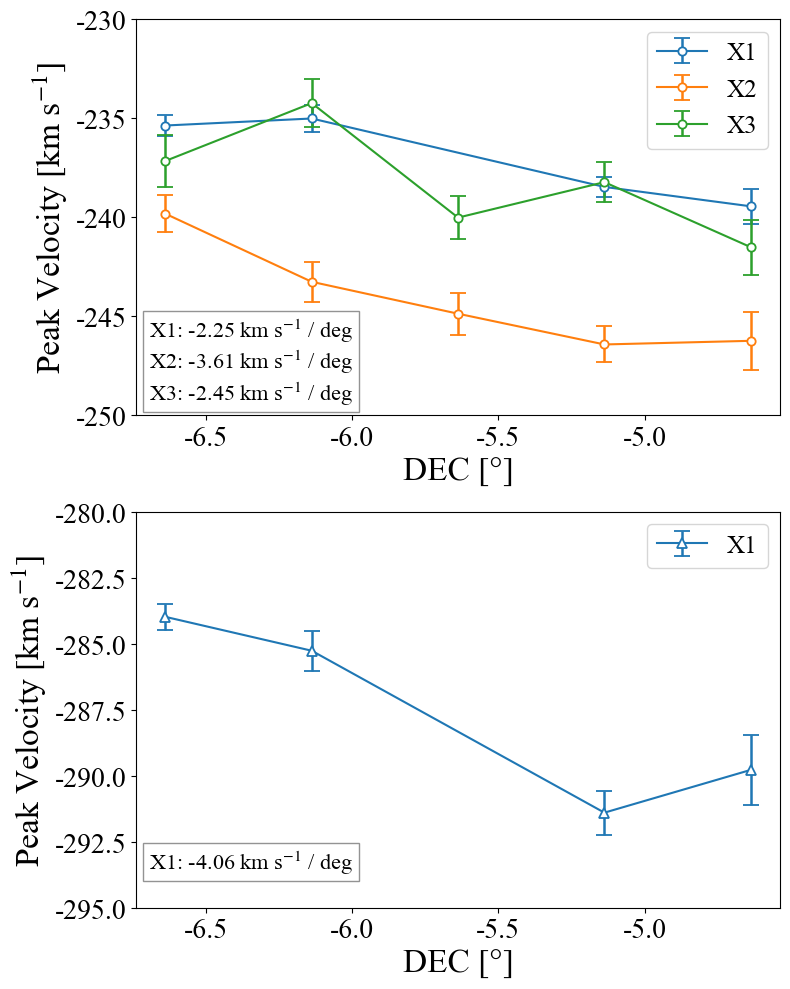

In [53]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix' 


# =========================
# 1. 读取 txt 文件
# =========================
txt_file = "./cut/new_baseline/PV_path_DEC0p5_peak_velocity_beam_corrected_two_peak_checked.txt"
df = pd.read_csv(txt_file, sep="\t")

print(df.columns)
print(df.head())

# =========================
# 2. 颜色设置
# =========================
path_colors = {
    "X1": "tab:blue",
    "X2": "tab:orange",
    "X3": "tab:green"
}
default_color = "black"

# =========================
# 3. 定义拟合函数
# =========================
def weighted_linear_fit(x, y, yerr=None):
    """
    对 y = a*x + b 做线性拟合
    返回 a, b
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    if yerr is not None:
        yerr = np.asarray(yerr, dtype=float)
        mask &= np.isfinite(yerr) & (yerr > 0)

    x = x[mask]
    y = y[mask]

    if yerr is not None:
        yerr = yerr[mask]

    # 至少需要两个点
    if len(x) < 2:
        return np.nan, np.nan

    # 若提供误差，则做加权拟合
    if yerr is not None and len(yerr) == len(x):
        coeff = np.polyfit(x, y, 1, w=1.0 / yerr)
    else:
        coeff = np.polyfit(x, y, 1)

    a, b = coeff[0], coeff[1]
    return a, b


# =========================
# 4. 建立上下两张子图
# =========================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=False, sharey=False)

# 用来存储变化率文字
slope_text_240 = []
slope_text_280 = []

# =========================
# 5. 循环画图 + 拟合
# =========================
for path_name in ["X1", "X2", "X3"]:
    sub = df[df["Path"] == path_name].copy()

    if len(sub) == 0:
        continue

    sub = sub.sort_values("DEC_center_deg")
    color = path_colors.get(path_name, default_color)

    # -------------------------
    # 上图：240 km/s 分量
    # -------------------------
    sub240 = sub[["DEC_center_deg", "V_mean_240_kms", "V_err_240_kms"]].dropna()

    if len(sub240) > 1:
        x240 = sub240["DEC_center_deg"].values
        y240 = sub240["V_mean_240_kms"].values
        yerr240 = sub240["V_err_240_kms"].values

        # 原始数据 + 误差棒
        ax1.errorbar(
            x240, y240, yerr=yerr240,
            fmt="o-",
            color=color,
            ecolor=color,
            capsize=6,
            capthick=1.8,
            elinewidth=1.8,
            markersize=6,
            markerfacecolor="white",
            markeredgewidth=1.3,
            linewidth=1.5,
            label=path_name
        )

        # 拟合
        a240, b240 = weighted_linear_fit(x240, y240, yerr240)

        # 画拟合直线
        if np.isfinite(a240):
            xfit = np.linspace(np.nanmin(x240), np.nanmax(x240), 200)
            yfit = a240 * xfit + b240
            # ax1.plot(xfit, yfit, "--", color=color, linewidth=2)

            slope_text_240.append(
                f"{path_name}: {a240:+.2f} km s$^{{-1}}$ / deg"
            )

    # -------------------------
    # 下图：280 km/s 分量
    # -------------------------
    sub280 = sub[["DEC_center_deg", "V_mean_280_kms", "V_err_280_kms"]].dropna()

    if len(sub280) > 1:
        x280 = sub280["DEC_center_deg"].values
        y280 = sub280["V_mean_280_kms"].values
        yerr280 = sub280["V_err_280_kms"].values

        # 原始数据 + 误差棒
        ax2.errorbar(
            x280, y280, yerr=yerr280,
            fmt="^-",
            color=color,
            ecolor=color,
            capsize=6,
            capthick=1.8,
            elinewidth=1.8,
            markersize=7,
            markerfacecolor="white",
            markeredgewidth=1.3,
            linewidth=1.5,
            label=path_name
        )

        # 拟合
        a280, b280 = weighted_linear_fit(x280, y280, yerr280)

        # 画拟合直线
        if np.isfinite(a280):
            xfit = np.linspace(np.nanmin(x280), np.nanmax(x280), 200)
            yfit = a280 * xfit + b280
            # ax2.plot(xfit, yfit, "--", color=color, linewidth=2)

            slope_text_280.append(
                f"{path_name}: {a280:+.2f} km s$^{{-1}}$ / deg"
            )

# =========================
# 6. 上图设置（240 km/s）
# =========================
ax1.set_xlabel("DEC [°]", fontsize=24)
ax1.set_ylabel("Peak Velocity [km s$^{-1}$]", fontsize=24)
# ax1.set_title("Peak Velocity vs DEC", fontsize=18)
ax1.set_ylim(-250, -230)
# ax1.grid(True, alpha=0.3)
ax1.tick_params(labelsize=20)
ax1.legend(fontsize=18)

# 标注变化率
ax1.text(
    0.02, 0.25,
    "\n".join(slope_text_240),
    transform=ax1.transAxes,
    fontsize=16,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85)
)

# =========================
# 7. 下图设置（280 km/s）
# =========================
ax2.set_xlabel("DEC [°]", fontsize=24)
ax2.set_ylabel("Peak Velocity [km s$^{-1}$]", fontsize=24)
# ax2.set_title("~280 km/s Component", fontsize=15)
ax2.set_ylim(-295, -280)
# ax2.set_xlim(-6.75, -6.0)
# ax2.grid(True, alpha=0.3)
ax2.tick_params(labelsize=20)
ax2.legend(fontsize=18)

# 标注变化率
ax2.text(
    0.02, 0.15,
    "\n".join(slope_text_280),
    transform=ax2.transAxes,
    fontsize=16,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85)
)

# =========================
# 8. 布局
# =========================
plt.tight_layout()

# plt.savefig("./cut/photo/PeakVelocity__fit.pdf", dpi=300, bbox_inches="tight")
plt.show()